impor Libararies

In [147]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
 
from sklearn.model_selection import GridSearchCV, cross_val_score

from imblearn.over_sampling import SMOTE



load data

In [148]:
file="heart_failure_clinical_records_dataset.csv"
data=pd.read_csv(file)
data.head()
data.tail()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
294,62.0,0,61,1,38,1,155000.0,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1,1,280,0
298,50.0,0,196,0,45,0,395000.0,1.6,136,1,1,285,0


processing

In [149]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [150]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [151]:
data.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

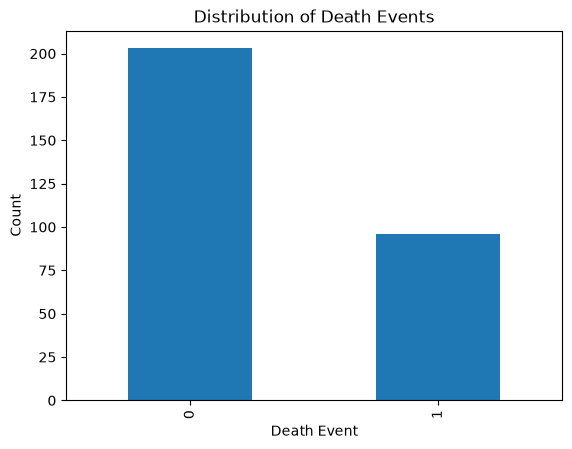

In [152]:
data["DEATH_EVENT"].value_counts().plot(kind="bar")

plt.xlabel("Death Event")
plt.ylabel("Count")
plt.title("Distribution of Death Events")
plt.show()

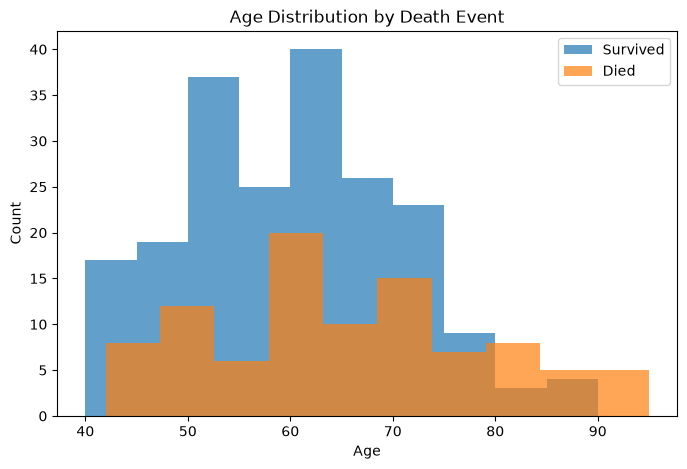

In [153]:
survived = data[data["DEATH_EVENT"] == 0]["age"]
died = data[data["DEATH_EVENT"] == 1]["age"]
plt.figure(figsize=(8,5))

plt.hist(survived, bins=10, alpha=0.7, label="Survived")
plt.hist(died, bins=10, alpha=0.7, label="Died")

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Death Event")
plt.legend()

plt.show()

In [154]:
num_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
creatinine_phosphokinase: 29 outliers
ejection_fraction: 2 outliers
platelets: 21 outliers
serum_creatinine: 29 outliers
serum_sodium: 4 outliers
time: 0 outliers


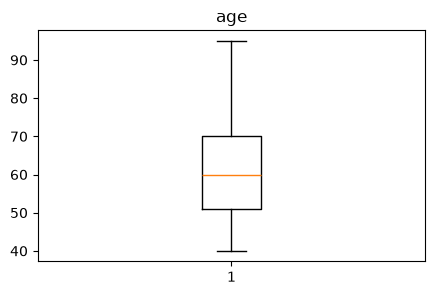

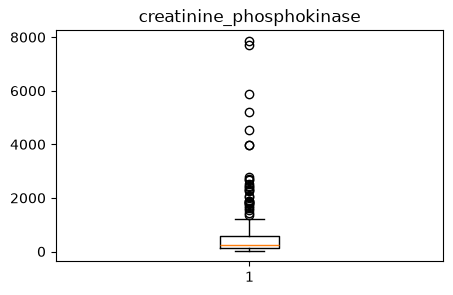

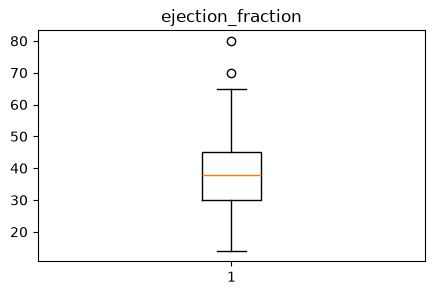

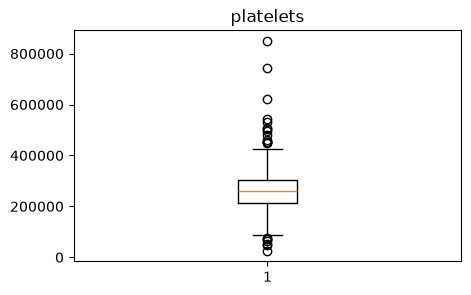

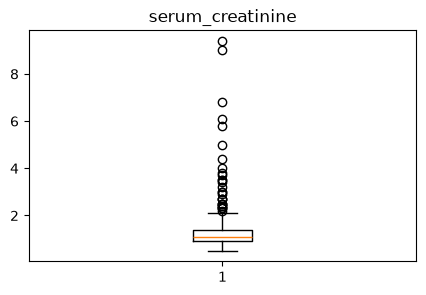

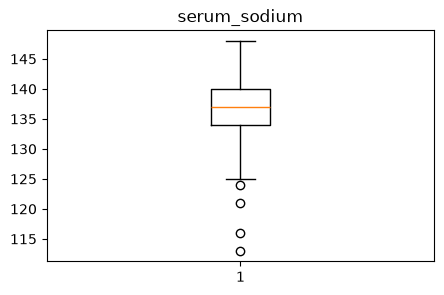

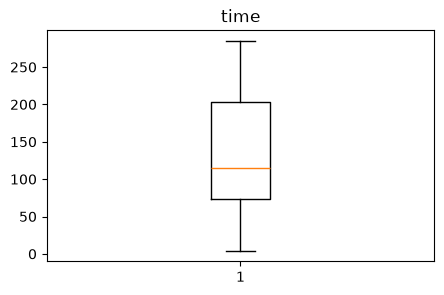

In [155]:
num_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(data[col])
    plt.title(col)
    plt.show()

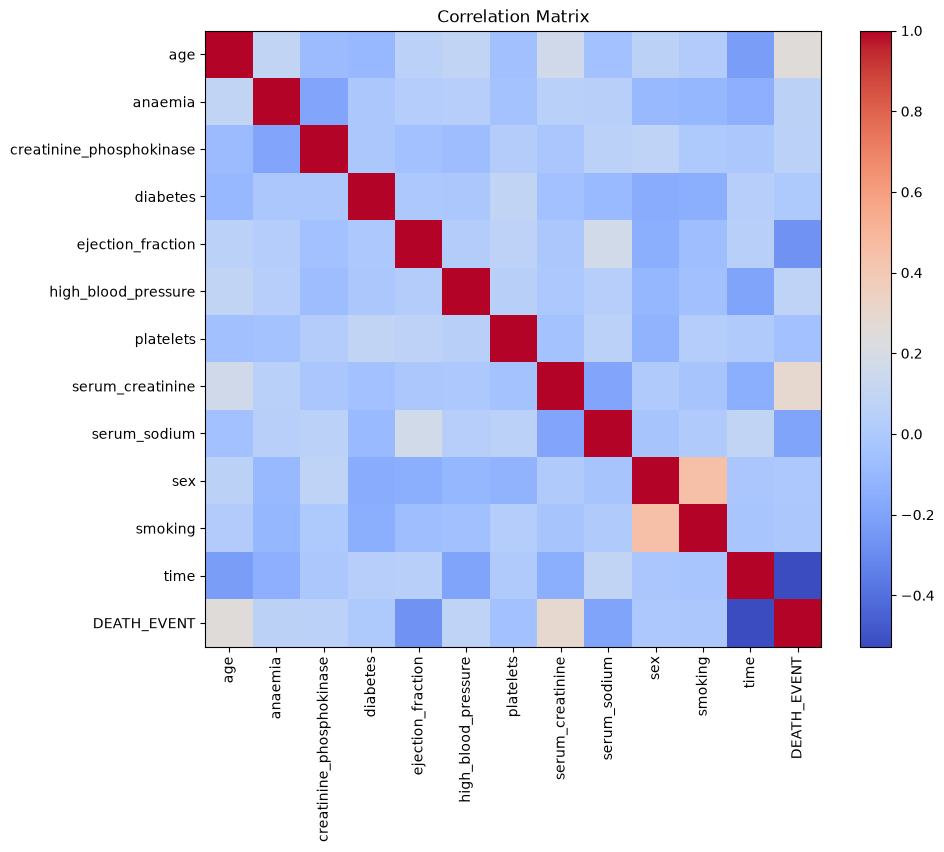

In [156]:
import matplotlib.pyplot as plt

corr_matrix = data.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")
plt.show()

In [157]:
data.corr()["DEATH_EVENT"].sort_values(ascending=False)

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64

MODEL BUILDING

In [158]:

X = data.drop(["DEATH_EVENT"], axis=1)
Y=data["DEATH_EVENT"]

In [159]:
scaler=StandardScaler().set_output(transform="pandas")
X_scaled=scaler.fit_transform(X)
X_scaled.describe()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
count,2.990000e+02,2.990000e+02,299.000000,2.990000e+02,2.990000e+02,299.000000,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02
mean,5.703353e-16,1.009969e-16,0.000000,9.060014e-17,-3.267546e-17,0.000000,7.723291e-17,1.425838e-16,-8.673849e-16,-8.911489e-18,-1.188199e-17,-1.901118e-16
std,1.001676e+00,1.001676e+00,1.001676,1.001676e+00,1.001676e+00,1.001676,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00
min,-1.754448e+00,-8.711048e-01,-0.576918,-8.475794e-01,-2.038387e+00,-0.735688,-2.440155e+00,-8.655094e-01,-5.363206e+00,-1.359272e+00,-6.876819e-01,-1.629502e+00
25%,-8.281242e-01,-8.711048e-01,-0.480393,-8.475794e-01,-6.841802e-01,-0.735688,-5.208700e-01,-4.782047e-01,-5.959961e-01,-1.359272e+00,-6.876819e-01,-7.389995e-01
50%,-7.022315e-02,-8.711048e-01,-0.342574,-8.475794e-01,-7.076750e-03,-0.735688,-1.390846e-02,-2.845524e-01,8.503384e-02,7.356882e-01,-6.876819e-01,-1.969543e-01
75%,7.718891e-01,1.147968e+00,0.000166,1.179830e+00,5.853888e-01,1.359272,4.111199e-01,5.926150e-03,7.660638e-01,7.356882e-01,1.454161e+00,9.387595e-01
max,2.877170e+00,1.147968e+00,7.514640,1.179830e+00,3.547716e+00,1.359272,6.008180e+00,7.752020e+00,2.582144e+00,7.356882e-01,1.454161e+00,1.997038e+00


using smote for imbalance in data that 

In [160]:

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.30)


sm = SMOTE(random_state=42)
X_train, Y_train = sm.fit_resample(X_train, Y_train)

Text(0, 0.5, 'numbers of instances')

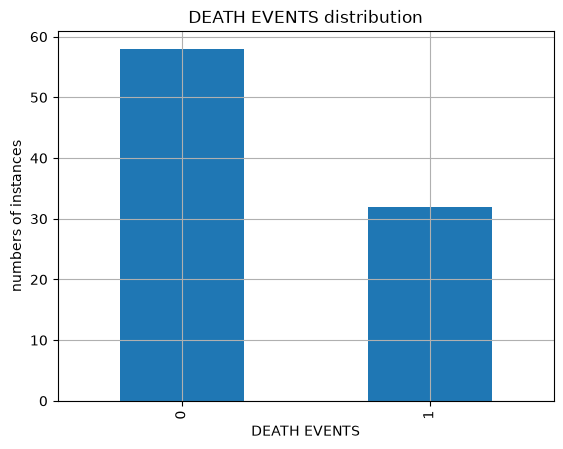

In [161]:
Y_test.value_counts().sort_index().plot.bar(grid="true")
plt.title("DEATH EVENTS distribution")
plt.xlabel("DEATH EVENTS")
plt.ylabel("numbers of instances")

Text(0, 0.5, 'numbers of instances')

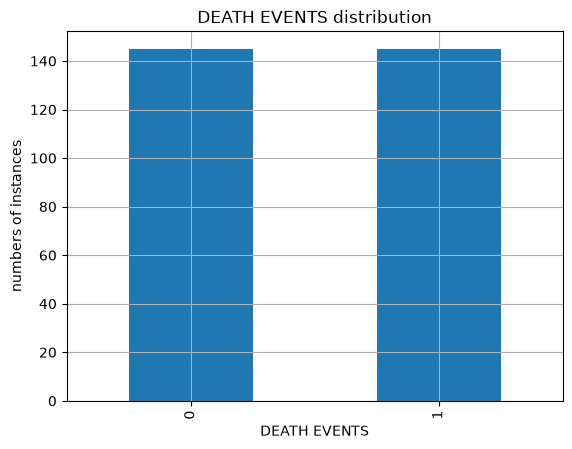

In [162]:
Y_train.value_counts().sort_index().plot.bar(grid="true")
plt.title("DEATH EVENTS distribution")
plt.xlabel("DEATH EVENTS")
plt.ylabel("numbers of instances")

SUPPORT VECTORE MACHINE 

In [163]:
print("using support vectore machine")
svm_model=svm.LinearSVC(class_weight="balanced")
svm_model.fit(X_train,Y_train)
prediction=svm_model.predict(X_test)
print("accuracy score:",accuracy_score(Y_test,prediction)*100)
print("precision score:",precision_score(Y_test,prediction)*100)
print("recall score:",recall_score(Y_test,prediction)*100)
print("f1 score:",f1_score(Y_test,prediction)*100)



using support vectore machine
accuracy score: 80.0
precision score: 70.58823529411765
recall score: 75.0
f1 score: 72.72727272727273


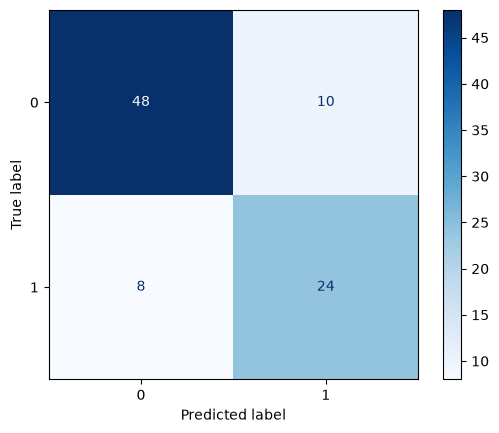

In [164]:


ConfusionMatrixDisplay.from_estimator(
    svm_model, 
    X_test, 
    Y_test, 
    cmap='Blues' 
)

plt.show()

KNeighborsClassifier

In [165]:
print("using Kneighbors classifier")
Knn_model=KNeighborsClassifier()
Knn_model.fit(X_train,Y_train)
prediction=Knn_model.predict(X_test)
print("accuracy score:",accuracy_score(Y_test,prediction)*100)
print("precision score:",precision_score(Y_test,prediction)*100)
print("recall score:",recall_score(Y_test,prediction)*100)
print("f1 score:",f1_score(Y_test,prediction)*100)



using Kneighbors classifier
accuracy score: 74.44444444444444
precision score: 65.51724137931035
recall score: 59.375
f1 score: 62.295081967213115


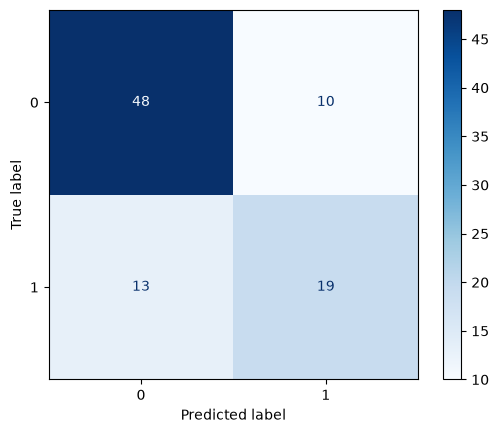

In [166]:


ConfusionMatrixDisplay.from_estimator(
    Knn_model, 
    X_test, 
    Y_test, 
    cmap='Blues' 
)

plt.show()

Logistic Regression

In [167]:
print("using logistic regression")
Lr_model=LogisticRegression(class_weight="balanced")
Lr_model.fit(X_train,Y_train)
prediction=Lr_model.predict(X_test)
print("accuracy score:",accuracy_score(Y_test,prediction)*100)
print("precision score:",precision_score(Y_test,prediction)*100)
print("recall score:",recall_score(Y_test,prediction)*100)
print("f1 score:",f1_score(Y_test,prediction)*100)



using logistic regression
accuracy score: 80.0
precision score: 70.58823529411765
recall score: 75.0
f1 score: 72.72727272727273


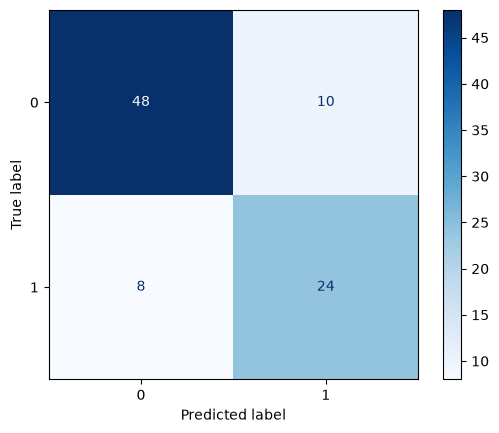

In [168]:
ConfusionMatrixDisplay.from_estimator(
    Lr_model, 
    X_test, 
    Y_test, 
    cmap='Blues' 
)

plt.show()

 using Random Forest Classifier
accuracy score: 83.33333333333334
precision score: 77.41935483870968
recall score: 75.0
f1 score: 76.19047619047619


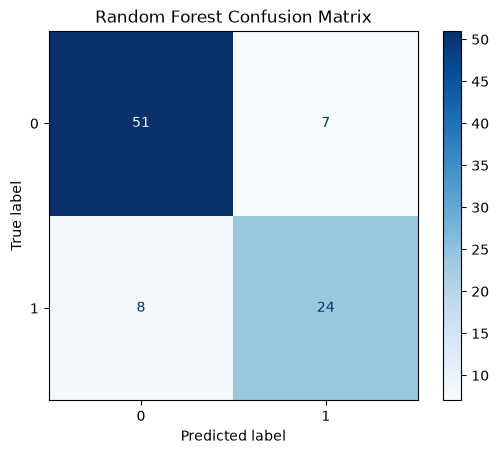

In [169]:
print(" using Random Forest Classifier")
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, Y_train)
prediction = rf_model.predict(X_test)
print("accuracy score:", accuracy_score(Y_test, prediction) * 100)
print("precision score:", precision_score(Y_test, prediction) * 100)
print("recall score:", recall_score(Y_test, prediction) * 100)
print("f1 score:", f1_score(Y_test, prediction) * 100)
 
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, Y_test, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()
 

 using XGBoost Classifier
accuracy score: 81.11111111111111
precision score: 74.19354838709677
recall score: 71.875
f1 score: 73.01587301587301


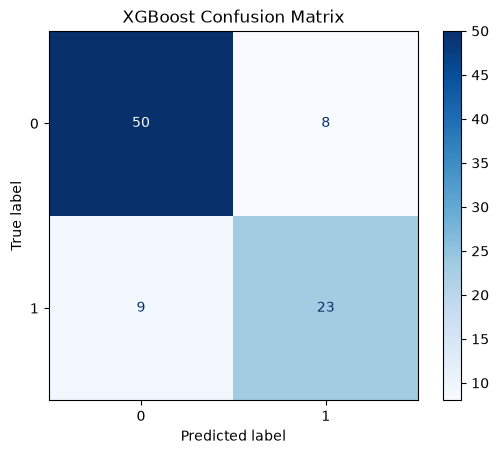

In [170]:
print(" using XGBoost Classifier")
xgb_model = XGBClassifier(
    scale_pos_weight=1,  
    random_state=42,
    eval_metric="logloss",
)
xgb_model.fit(X_train, Y_train)
prediction = xgb_model.predict(X_test)
print("accuracy score:", accuracy_score(Y_test, prediction) * 100)
print("precision score:", precision_score(Y_test, prediction) * 100)
print("recall score:", recall_score(Y_test, prediction) * 100)
print("f1 score:", f1_score(Y_test, prediction) * 100)
 
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, Y_test, cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [171]:

print("using GridSearchCV tuning on Random Forest (optimizing Recall)...")
 
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
}
 
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="recall",  
    n_jobs=-1,
    verbose=1,
)
 
grid_search.fit(X_train, Y_train)
 
print("Best parameters found:", grid_search.best_params_)
print("[Best cross-validated Recall:", grid_search.best_score_ * 100)
 

using GridSearchCV tuning on Random Forest (optimizing Recall)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
[Best cross-validated Recall: 91.03448275862067


 Tuned Random Forest Results:
accuracy score: 83.33333333333334
precision score: 77.41935483870968
recall score: 75.0
f1 score: 76.19047619047619


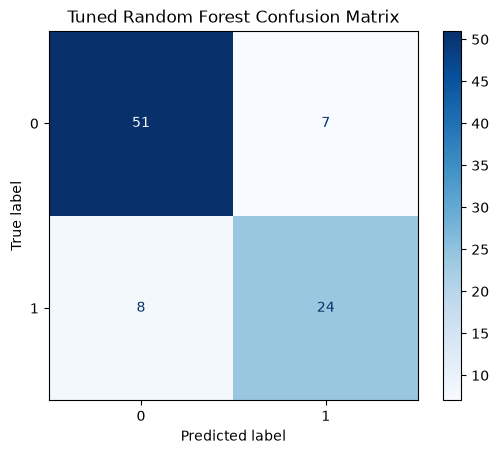

In [172]:
best_model = grid_search.best_estimator_
prediction = best_model.predict(X_test)
print(" Tuned Random Forest Results:")
print("accuracy score:", accuracy_score(Y_test, prediction) * 100)
print("precision score:", precision_score(Y_test, prediction) * 100)
print("recall score:", recall_score(Y_test, prediction) * 100)
print("f1 score:", f1_score(Y_test, prediction) * 100)
 
ConfusionMatrixDisplay.from_estimator(best_model, X_test, Y_test, cmap="Blues")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()
 

In [173]:

cv_recall = cross_val_score(best_model, X_scaled, Y, cv=10, scoring="recall")
cv_f1 = cross_val_score(best_model, X_scaled, Y, cv=10, scoring="f1")

print(f"Mean Recall: {cv_recall.mean()*100:.2f}% (+/- {cv_recall.std()*100:.2f}%)")
print(f"Mean F1: {cv_f1.mean()*100:.2f}% (+/- {cv_f1.std()*100:.2f}%)")

Mean Recall: 69.00% (+/- 38.49%)
Mean F1: 60.32% (+/- 30.79%)


In [174]:
print(" Final Model Comparison:")
 
models = {
    "SVM": svm_model,
    "KNN": Knn_model,
    "Logistic Regression": Lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Tuned Random Forest": best_model,
}
 
results = []
for name, model in models.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(Y_test, pred) * 100, 2),
        "Precision": round(precision_score(Y_test, pred) * 100, 2),
        "Recall": round(recall_score(Y_test, pred) * 100, 2),
        "F1 Score": round(f1_score(Y_test, pred) * 100, 2),
    })
 
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Final Model Comparison:
              Model  Accuracy  Precision  Recall  F1 Score
                SVM     80.00      70.59   75.00     72.73
                KNN     74.44      65.52   59.38     62.30
Logistic Regression     80.00      70.59   75.00     72.73
      Random Forest     83.33      77.42   75.00     76.19
            XGBoost     81.11      74.19   71.88     73.02
Tuned Random Forest     83.33      77.42   75.00     76.19
